In [4]:
import pandas as pd
from sqlalchemy import create_engine, text 
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import numpy as np

In [71]:
## Keys for acess the database
load_dotenv()

True

In [72]:
## Acessing the database throught SQLAlchemy -> the database is local
engine = create_engine(f"mysql+mysqlconnector://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@"
    f"{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}",
    echo=True)

In [ ]:
## Execute the SQL scripts,locate on sql/ using the connection of SQLAlchemy. The SQL files create .csv tables locate
## in /var/lib/mysql-files/
files = ['questionsxtags.sql', 'answersxtags.sql', 'tagsxyear.sql', 'tagxtime.sql']
for file in files:
    with engine.connect() as conn:
        with open(f'sql/{file}',"r", encoding="utf-8") as f:
            sql = f.read()
        conn.execute(text(sql)) # Read and pass the scripts in the .sql files. 'text' is used to pass the commands literally to MySQL
#Another way to perform is to use 'select' function from SQLAlchemy directly
        conn.commit() #Saves any changes made in the tables

### Before the next steps, it will be necessary to move the files locate on **`/var/lib/mysql-files/`** to /project/csv_analises or other location 
### of interest in order to perform the analysis. To do that, open the terminal and type
### **`cd /var/lib/mysql-files/`**
### It will require root credentials to acess the folder
### Move the files using:
### **`mv filename.txt /path/to/destination/`**
### It will be necessary to update the acess of the files in the new folder, giving permission to the user to acess the files:
### In the folder of the project, type
### **`chown user:user`**
### Now, you can proceed to run the analysis below

In [5]:
df_qxt = pd.read_csv('csv_analises/questionsxtags.csv', names = ['tag','quantity'])

In [9]:
df_qxt1 = df_qxt[df_qxt.index<20].copy() #Pick only the 20 more asked topics of data science in stack exchange

In [10]:
df_qxt1['tag'] = df_qxt1['tag'].str.replace("-", "\n") # improving the plot legends

[]

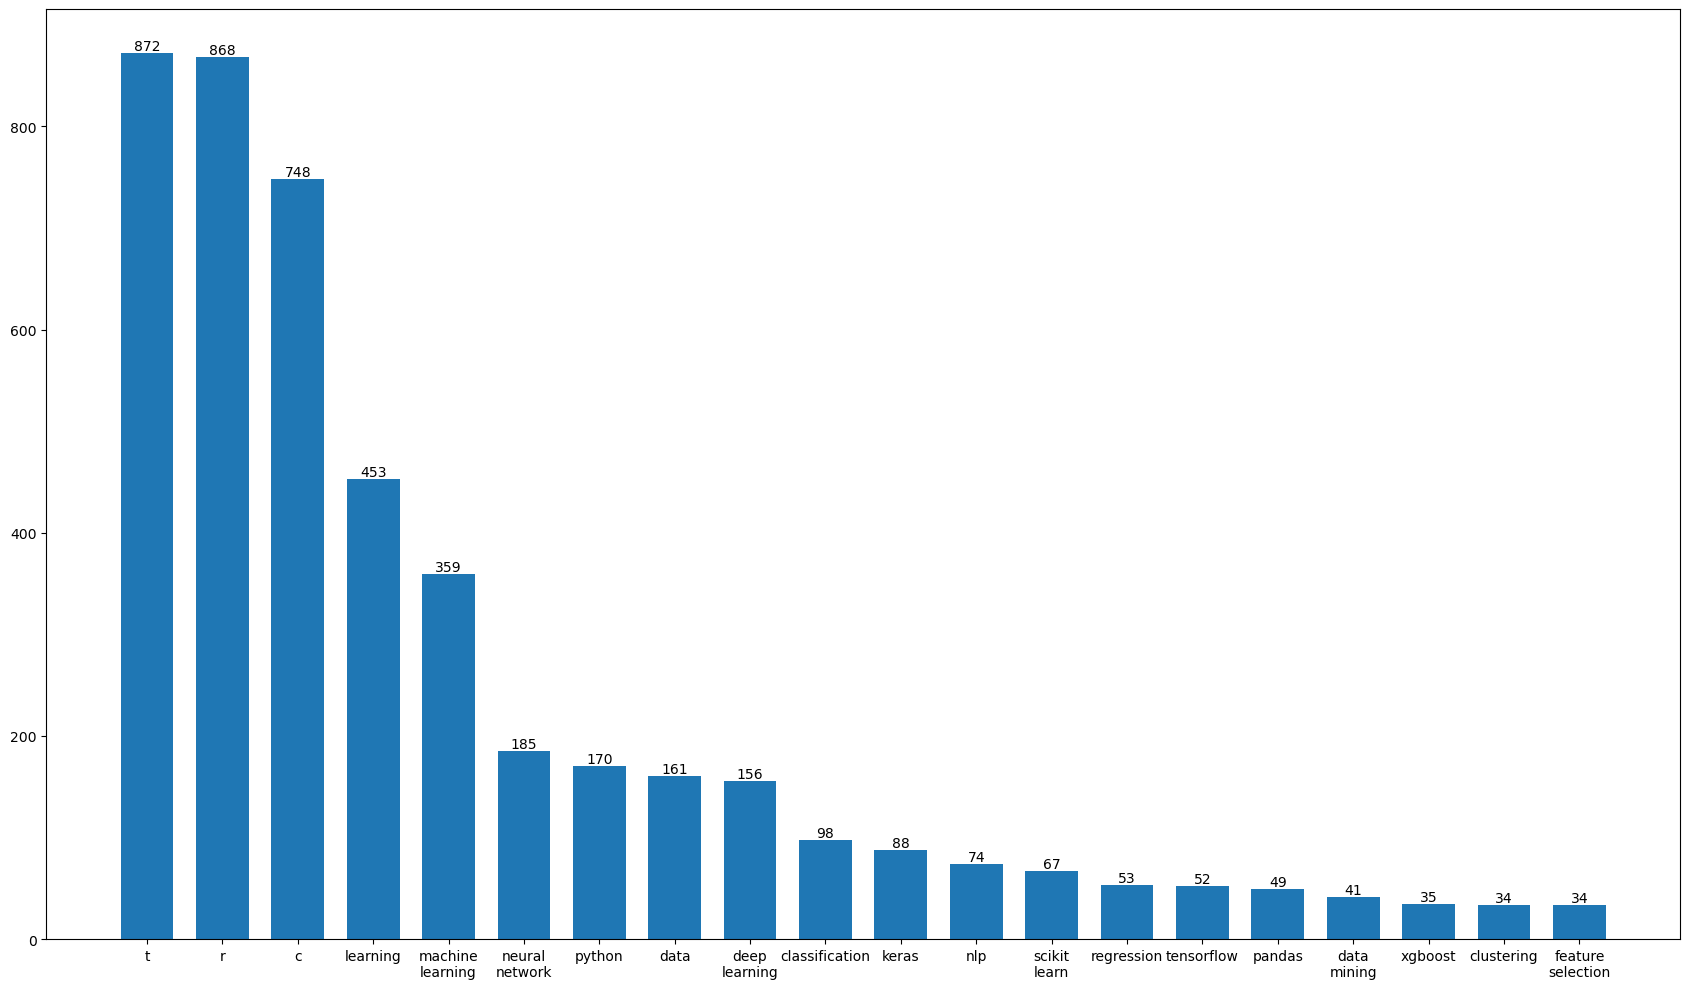

In [11]:
fig, ax = plt.subplots(figsize = (17,10))
graf = ax.bar(df_qxt1['tag'], df_qxt1['quantity'], width=0.7)
ax.bar_label(graf)
plt.tight_layout()
plt.plot()

### The query return that, in the period 2014-2022, the tecnologies with the most asked questions was r, C, machine-learning, neural network, python and deep-Learning
### This insight the increasing of interest in I.A tecnologies before the boom of I.A (around 2019-2020), mainly in the concept (machine-learning, deep-learning) instead of speecific applications and libraries such as scikit-learrn or tensorflow 

In [19]:
df_axt = pd.read_csv('csv_analises/answersxtags.csv', names = ['tag','quantity'])

In [20]:
df_axt1 = df_axt[df_axt['quantity']>10].sort_values('quantity',ascending=False).copy()
df_axt2 = df_axt1[df_axt1.index < 20].copy()
df_axt2['tag'] = df_axt2['tag'].str.replace("-", "\n")

[]

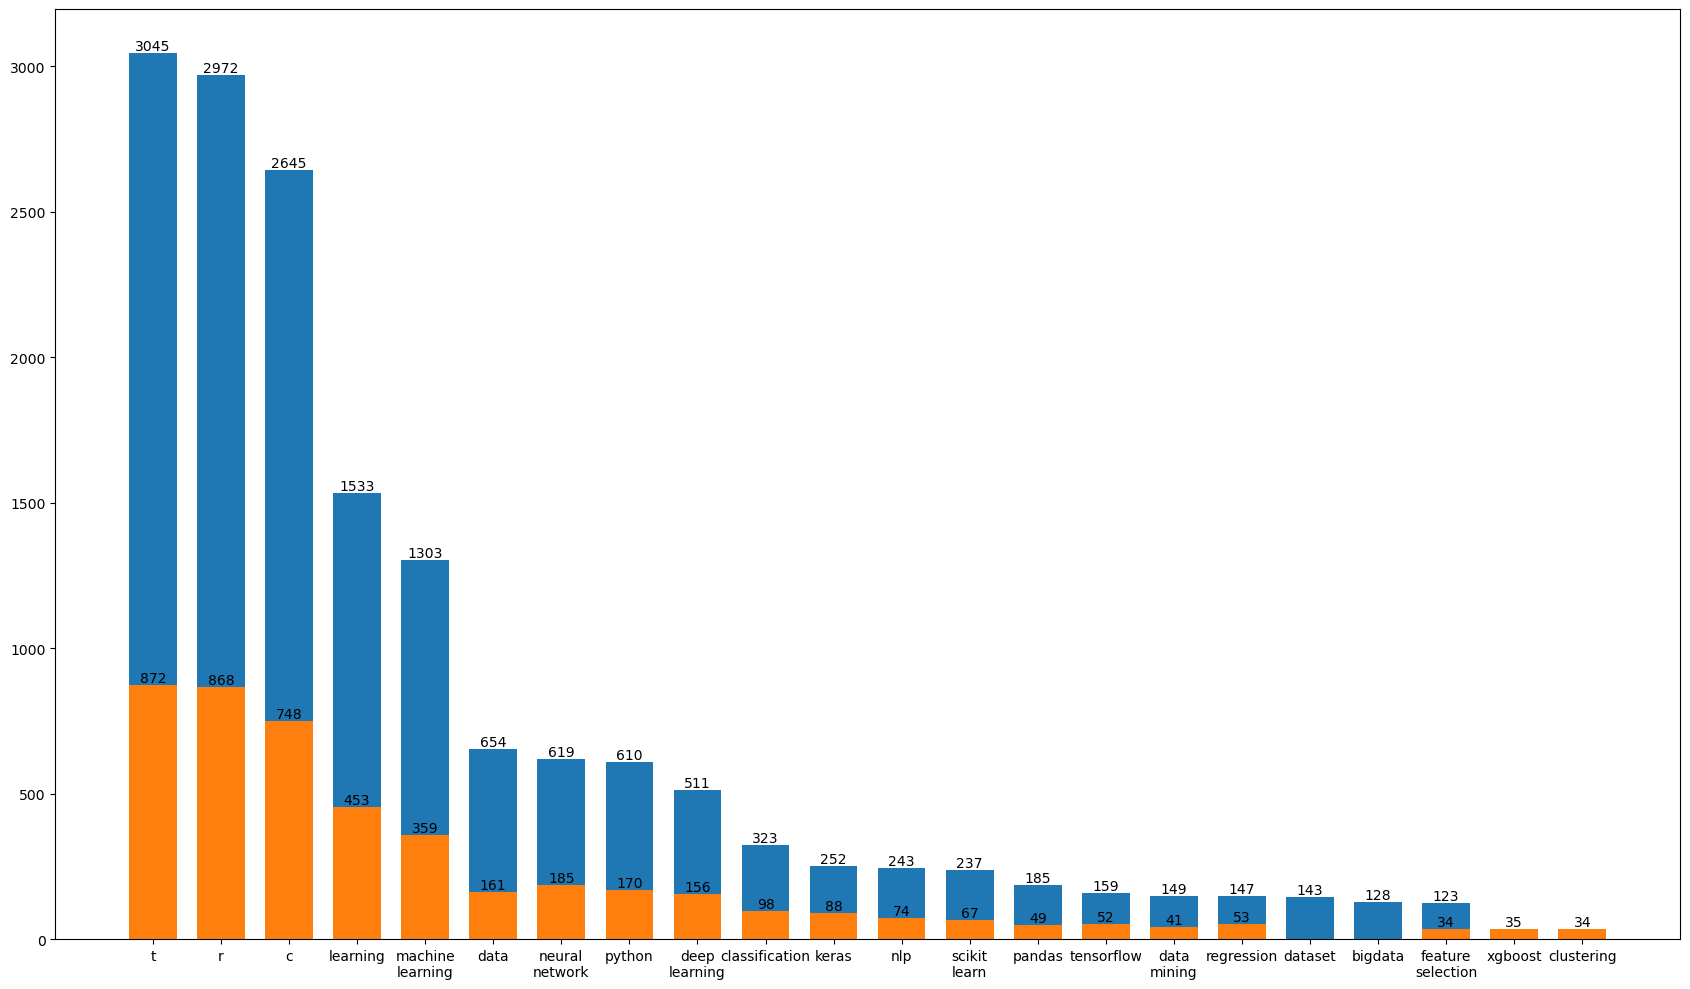

In [21]:
fig, ax = plt.subplots(figsize = (17,10))
graf = ax.bar(df_axt2['tag'], df_axt2['quantity'], width=0.7)
graf2 = ax.bar(df_qxt1['tag'], df_qxt1['quantity'], width=0.7)
ax.bar_label(graf)
ax.bar_label(graf2)
plt.tight_layout()
plt.plot()

### The graphic above show the quantity of answers (blue) and questions (orange) for each topic. For the majority of the topics, the most questions asked, more answers it get. The mean number of answers per topic is givin below. The lowest answer rate belong to keras, and the highest is python questions

In [32]:
df_mean = pd.DataFrame()
df_mean['Tag'] = df_axt2['tag'].reset_index(drop=True)
df_mean['Answers/questions'] = (
    df_axt2['quantity'].reset_index(drop=True) /
    df_qxt1['quantity'].reset_index(drop=True)
)
print(df_mean)

                   Tag  Answers/questions
0                    t           3.491972
1                    r           3.423963
2                    c           3.536096
3             learning           3.384106
4    machine\nlearning           3.629526
5                 data           3.535135
6      neural\nnetwork           3.641176
7               python           3.788820
8       deep\nlearning           3.275641
9       classification           3.295918
10               keras           2.863636
11                 nlp           3.283784
12       scikit\nlearn           3.537313
13              pandas           3.490566
14          tensorflow           3.057692
15        data\nmining           3.040816
16          regression           3.585366
17             dataset           4.085714
18             bigdata           3.764706
19  feature\nselection           3.617647


### The analysis below was written to be consultant -> type the tag you want to analyze. The graphics below will show the evolution of questions about that tag in years (left) and months (right).

In [34]:
df_txt = pd.read_csv('csv_analises/timextags.csv', names = ['tag','year','month','qnt'])

Tag de interesse:  python


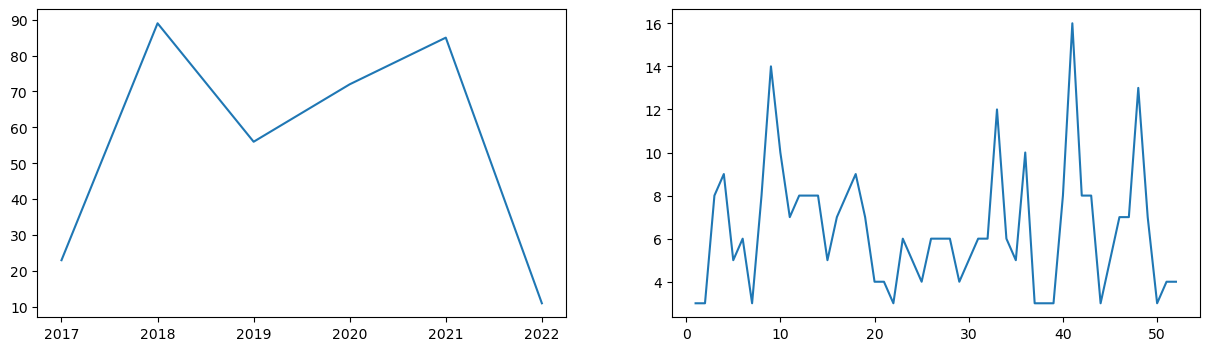

In [51]:
consulta = input("Tag de interesse: ")
df_cons = df_txt[df_txt['tag'] == consulta]
if df_cons.empty:
    print("Tag não encontrada, escolha uma das tags abaixo:")
    print(df_txt['tag'].unique())
else:
    df_cons_y = df_cons.groupby('year')['qnt'].sum()
    fig, ax = plt.subplots(1,2, figsize=(15,4))
    meses = np.linspace(1, len(df_cons['month']), len(df_cons['month']))
    ax[0].plot(df_cons_y)
    ax[1].plot(meses, df_cons['qnt'])

## As in the previous analysis, below you can consult the evolution of the difference between the quantity os questions asked throught the years

In [52]:
df_txy = pd.read_csv('csv_analises/tagsxyear.csv', names=['tag','years','n_questions','last year', 'cy-ly'])

Tag de interesse:  python


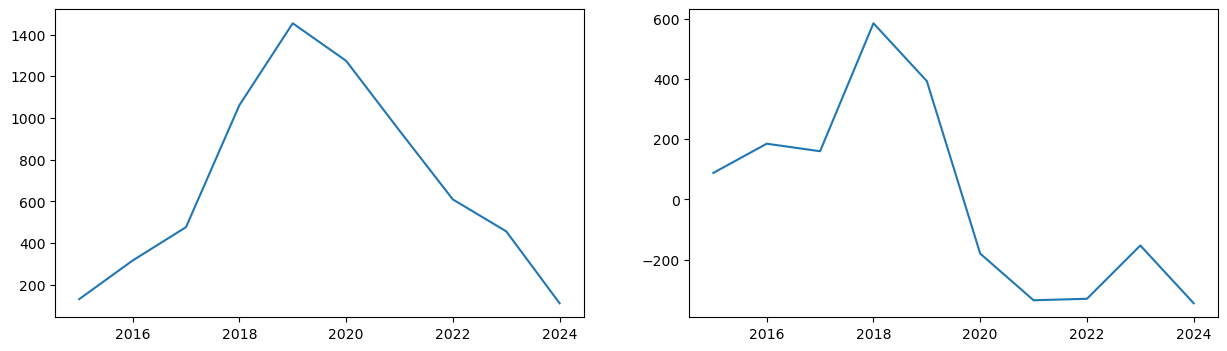

In [57]:
consulta = input("Tag de interesse: ")
df_txy_cons = df_txy[df_txy['tag'] == consulta]
if df_txy_cons.empty:
    print("Tag não encontrada, escolha uma das tags abaixo:")
    print(df_txy['tag'].unique())
else:
    df_txy_cons = df_txy_cons[df_txy_cons.index>df_txy_cons.index[0]] 
    fig, ax = plt.subplots(1,2, figsize=(15,4))
    ax[0].plot(df_txy_cons['years'], df_txy_cons['n_questions'])
    ax[1].plot(df_txy_cons['years'], pd.to_numeric(df_txy_cons['cy-ly']))